In this section we will simulate **a random walk** on the 2D Torus on $(\mathbb{Z}/N\mathbb{Z})^2$ and then estimate the constant $\tau_{mix}$ 

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 

In [3]:
# We first define the constants
p_1 = 1/np.sqrt(2)
p_2 = 0
p_3 = 0.7
N = 500
iteration_count = 4000
number_deltas = 50
x, y = 0, 0

In this chain, we go right with probability $p$ and up with probability $1-p$.

To estimate the optimal $m_1$ and $m_2$ we solve the equation

In [4]:
# step transition probabilities
def take_step(x, y, p):
    generated_prob = np.random.random()

    if generated_prob > p:
        return (x+1) % N, y 
    else:
        return x, (y+1) % N

# try all combinations lol
def find_opt_int(N, p):
    L = int(np.floor(N**(1/3)))
    minimum = 10000
    min_m1, min_m2 = -1000, -1000
    for m_1 in range(-2*L, 2*L, 1):
        for m_2 in range(-2*L, 2*L, 1):
            if m_1 == 0 and m_2 == 0:
                continue
            diophan = np.absolute(p*m_1 + (1-p)*m_2)
            if diophan < minimum:
                minimum = diophan
                min_m1 = m_1
                min_m2 = m_2
    return min_m1, min_m2

In [5]:
m_1_irrational, m_2_irrational = find_opt_int(N, p_1)

We compute $\Delta_n = \sqrt{\bar{W}}$, where we define $W$ as
\begin{equation}
| \frac{1}{n}\sum\limits_{i=1}^{n-1}f(X_i) - \mathbb{E}[f(X)] |
\end{equation}

We know from 3.17 page 22 of the paper that for a rational p, we have that the supremum function is
\begin{equation}
f(x) = e^{\frac{2\pi i}{N}\sum\limits_{j=1}^{d}m_jx_j}
\end{equation}
with the constraint that $m_1, \dots, m_d \in \mathbb{Z}$ are not all zero and verify the property 
\begin{equation}
\sum\limits_{j=1}^{d}m_j(p_j-p_{-j}).
\end{equation}

In our case we have $m_1 \cdot p + m_2 \cdot(1-p) = 0$, and setting $p=0.7$ we obtain $0.7m_1 + 0.3m_2 = 0$ where we pick $m_1 = 3$ and $m_2 = -7$

\begin{equation}
\Delta_n = \sqrt{\mathbb{E}[\frac{1}{n^2}(\sum\limits_{k=0}^{n-1}cos(\frac{2\pi}{N}(m_1x_k+m_2y_k))^2 + (\sum\limits_{k=0}^{n-1}sin(\frac{2\pi}{N}(m_1x_k+m_2y_k)))^2)]}
\end{equation}

In [6]:
def compute_delta(p, m_1, m_2):
    print(p)
    all_deltas = np.zeros((number_deltas, iteration_count))

    for j in range(number_deltas):
        curr_x, curr_y = 0, 0
        val_sin = 0
        val_cos = 0

        for i in range(iteration_count):
            # take a step, then compute f
            curr_x, curr_y = take_step(curr_x, curr_y, p)
            val_sin += np.sin(2*np.pi*(m_1*curr_x + m_2*curr_y)/N)
            val_cos += np.cos(2*np.pi*(m_1*curr_x + m_2*curr_y)/N)
            # compute empirical average of f after drawing i samples
            f_sum = val_sin**2 + val_cos**2 
            all_deltas[j, i] = f_sum/(i+1)**2

    delta_n = np.sqrt(np.mean(all_deltas, axis=0))
    return delta_n

In [7]:
delta_n_1 = compute_delta(p_1, m_1_irrational, m_2_irrational) # sqrt
delta_n_3 = compute_delta(p_3, 3, -7) # rational

0.7071067811865475
0.7


Now we plot $\Delta_n$ for all the different transition probabilities

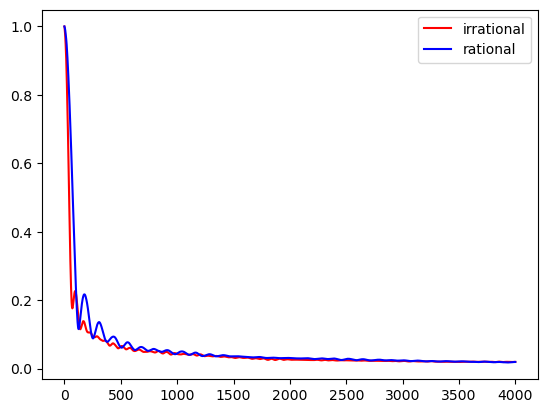

In [8]:
plt.plot(range(iteration_count), delta_n_1, c="r", label="irrational")
plt.plot(range(iteration_count), delta_n_3, c="b", label="rational")
#plt.plot(range(iteration_count), [np.sqrt(0.2 * N**(4/3)/n) for n in range(1, iteration_count+1)], c="b", label="relaxation time")
plt.legend()

We now estimate $\tau$. We do that by finding a constant such that $\tau \geq \frac{n\Delta_n^2}{4}, \forall n \geq 1$

In [10]:
def compute_tau(delta):
    big_tau = -10

    for k in range(len(delta)):
        delta_k = delta[k]
        const = k*(delta_k**2)*1/4
        if big_tau < const:
            big_tau = const 
    return big_tau

In [13]:
tau_irrational = compute_tau(delta_n_1)
tau_irrational

np.float64(3.9099918656802397)

In [14]:
tau_rational = compute_tau(delta_n_3)
tau_rational

np.float64(6.813734513952452)

Now we plot the different $\Delta_n$ against $\sqrt{\frac{4\tau}{n}}$, where 

C:\Users\User\AppData\Local\Temp\ipykernel_13476\3988238463.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  tau_series = [np.sqrt(4*tau_irrational/n) for n in range(0, iteration_count, 1)]


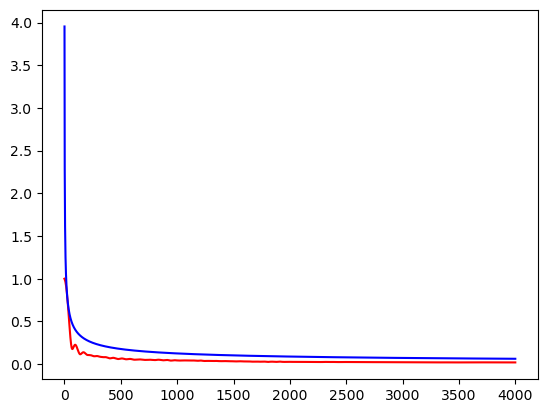

In [26]:
plt.plot(range(iteration_count), delta_n_1, c="r", label="irrational")
tau_series = [np.sqrt(4*tau_irrational/n) for n in range(0, iteration_count, 1)]
plt.plot(range(iteration_count), tau_series, c='b')

C:\Users\User\AppData\Local\Temp\ipykernel_13476\3522009561.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  tau_series = [np.sqrt(4*tau_rational/n) for n in range(0, iteration_count, 1)]


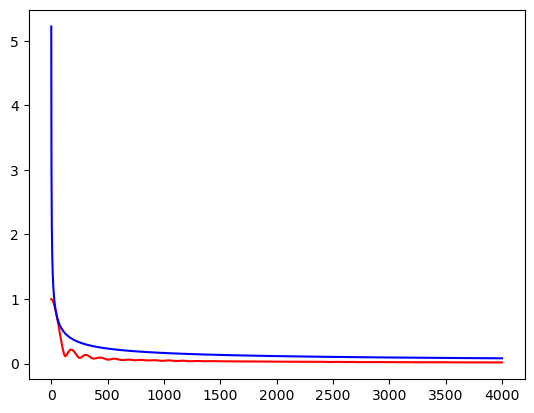

In [27]:
plt.plot(range(iteration_count), delta_n_3, c="r", label="irrational")
tau_series = [np.sqrt(4*tau_rational/n) for n in range(0, iteration_count, 1)]
plt.plot(range(iteration_count), tau_series, c='b')